In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_full = datasets.GTSRB(root='./data', split='train', transform=transform_train, download=True)
test_dataset = datasets.GTSRB(root='./data', split='test', transform=transform_test, download=True)

train_size = int(0.9 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

100%|██████████| 187M/187M [00:11<00:00, 15.9MB/s] 
100%|██████████| 89.0M/89.0M [00:07<00:00, 12.3MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 278kB/s]


Train: 23976, Val: 2664, Test: 12630


In [3]:
def apply_gaussian_blur(image, severity=1):
    kernel_sizes = [3, 5, 7, 9, 11]
    ksize = kernel_sizes[severity - 1]
    img_array = np.array(image)
    blurred = cv2.GaussianBlur(img_array, (ksize, ksize), 0)
    return Image.fromarray(blurred)

def apply_noise(image, severity=1):
    noise_levels = [5, 10, 20, 35, 50]
    noise_std = noise_levels[severity - 1]
    img_array = np.array(image).astype(np.float32)
    noise = np.random.normal(0, noise_std, img_array.shape)
    noisy = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def apply_brightness(image, severity=1):
    brightness_factors = [0.8, 0.6, 0.4, 0.2, 0.1]
    factor = brightness_factors[severity - 1]
    img_array = np.array(image).astype(np.float32)
    darkened = np.clip(img_array * factor, 0, 255).astype(np.uint8)
    return Image.fromarray(darkened)

def apply_fog(image, severity=1):
    fog_intensities = [0.2, 0.35, 0.5, 0.65, 0.8]
    fog_intensity = fog_intensities[severity - 1]
    img_array = np.array(image).astype(np.float32)
    fog_layer = np.ones_like(img_array) * 255
    fogged = img_array * (1 - fog_intensity) + fog_layer * fog_intensity
    fogged = np.clip(fogged, 0, 255).astype(np.uint8)
    return Image.fromarray(fogged)

print("Degradation functions defined!")

Degradation functions defined!


In [4]:
# Train original ResNet18 (no augmentation)
model_resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 43)
model_resnet = model_resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=0.0001)

best_val = 0
for epoch in range(4):
    model_resnet.train()
    correct, total = 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/4"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100 * correct / total
    
    model_resnet.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1}: Train={train_acc:.2f}%, Val={val_acc:.2f}%")
    
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model_resnet.state_dict(), '/kaggle/working/resnet_original.pth')

print(f"Best Val: {best_val:.2f}%")

# Test on clean images
model_resnet.load_state_dict(torch.load('/kaggle/working/resnet_original.pth'))
model_resnet.eval()
preds, labs = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = outputs.max(1)
        preds.extend(predicted.cpu().numpy())
        labs.extend(labels.cpu().numpy())

orig_clean = accuracy_score(labs, preds) * 100
print(f"Original ResNet18 Clean Accuracy: {orig_clean:.2f}%")
torch.save(model_resnet.state_dict(), '/kaggle/working/resnet_original_final.pth')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s] 
Epoch 1/4: 100%|██████████| 375/375 [01:13<00:00,  5.07it/s]


Epoch 1: Train=89.64%, Val=98.95%


Epoch 2/4: 100%|██████████| 375/375 [01:14<00:00,  5.00it/s]


Epoch 2: Train=99.41%, Val=99.77%


...

Epoch 3: Train=99.68%, Val=99.70%


Epoch 4/4: 100%|██████████| 375/375 [01:16<00:00,  4.93it/s]


Epoch 4: Train=99.82%, Val=99.92%
Best Val: 99.92%


Testing: 100%|██████████| 198/198 [00:15<00:00, 12.81it/s]

Original ResNet18 Clean Accuracy: 95.99%


In [5]:
import gc
del model_resnet
torch.cuda.empty_cache()
gc.collect()
print("GPU memory cleared!")

GPU memory cleared!


In [6]:
# Train augmented ResNet18 (with degradation augmentation)
class DegradationAugmentation:
    def __init__(self, p=0.5):
        self.p = p
    
    def __call__(self, img):
        if random.random() < self.p:
            deg_type = random.choice(['blur', 'noise', 'brightness', 'fog'])
            severity = random.randint(1, 3)
            if deg_type == 'blur':
                img = apply_gaussian_blur(img, severity)
            elif deg_type == 'noise':
                img = apply_noise(img, severity)
            elif deg_type == 'brightness':
                img = apply_brightness(img, severity)
            else:
                img = apply_fog(img, severity)
        return img

transform_train_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    DegradationAugmentation(p=0.5),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_aug_full = datasets.GTSRB(root='./data', split='train', transform=transform_train_aug, download=False)
train_aug, val_aug = random_split(train_aug_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_loader_aug = DataLoader(train_aug, batch_size=64, shuffle=True, num_workers=2)

model_resnet_aug = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_resnet_aug.fc = nn.Linear(model_resnet_aug.fc.in_features, 43)
model_resnet_aug = model_resnet_aug.to(device)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_resnet_aug.parameters(), lr=0.0001)

best_val_aug = 0
for epoch in range(4):
    model_resnet_aug.train()
    correct, total = 0, 0
    for images, labels in tqdm(train_loader_aug, desc=f"Epoch {epoch+1}/4"):
        images, labels = images.to(device), labels.to(device)
        optimizer_aug.zero_grad()
        outputs = model_resnet_aug(images)
        loss = criterion_aug(outputs, labels)
        loss.backward()
        optimizer_aug.step()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100 * correct / total
    
    model_resnet_aug.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet_aug(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1}: Train={train_acc:.2f}%, Val={val_acc:.2f}%")
    
    if val_acc > best_val_aug:
        best_val_aug = val_acc
        torch.save(model_resnet_aug.state_dict(), '/kaggle/working/resnet_aug.pth')

print(f"Best Val: {best_val_aug:.2f}%")

# Test on clean
model_resnet_aug.load_state_dict(torch.load('/kaggle/working/resnet_aug.pth'))
model_resnet_aug.eval()
preds_aug, labs_aug = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing Augmented"):
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet_aug(images)
        _, predicted = outputs.max(1)
        preds_aug.extend(predicted.cpu().numpy())
        labs_aug.extend(labels.cpu().numpy())

aug_clean = accuracy_score(labs_aug, preds_aug) * 100
print(f"Augmented ResNet18 Clean Accuracy: {aug_clean:.2f}%")
print(f"Original ResNet18 Clean Accuracy:  {orig_clean:.2f}%")
print(f"Difference: {aug_clean - orig_clean:+.2f}%")

Epoch 1/4: 100%|██████████| 375/375 [01:16<00:00,  4.89it/s]


Epoch 1: Train=87.74%, Val=97.11%


Epoch 2/4: 100%|██████████| 375/375 [01:16<00:00,  4.92it/s]


Epoch 2: Train=99.06%, Val=99.47%


Epoch 3/4: 100%|██████████| 375/375 [01:16<00:00,  4.92it/s]


Epoch 3: Train=99.62%, Val=99.81%


Epoch 4/4: 100%|██████████| 375/375 [01:16<00:00,  4.92it/s]


Epoch 4: Train=99.67%, Val=99.89%
Best Val: 99.89%


Testing Augmented: 100%|██████████| 198/198 [00:15<00:00, 13.17it/s]


Augmented ResNet18 Clean Accuracy: 96.56%
Original ResNet18 Clean Accuracy:  95.99%
Difference: +0.57%


In [7]:
# Compare robustness: Original vs Augmented ResNet18
def get_degraded_loader(degradation_fn, severity, batch_size=64):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    to_tensor = transforms.ToTensor()
    resize = transforms.Resize((224, 224))
    
    raw_test = datasets.GTSRB(root='./data', split='test', transform=None, download=False)
    degraded_images = []
    labels_list = []
    
    for i in range(len(raw_test)):
        img, label = raw_test[i]
        img_degraded = degradation_fn(img, severity)
        img_tensor = to_tensor(img_degraded)
        img_tensor = resize(img_tensor)
        img_tensor = normalize(img_tensor)
        degraded_images.append(img_tensor)
        labels_list.append(label)
    
    dataset = torch.utils.data.TensorDataset(
        torch.stack(degraded_images),
        torch.tensor(labels_list)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100 * correct / total

# Load both models
model_orig = models.resnet18(weights=None)
model_orig.fc = nn.Linear(model_orig.fc.in_features, 43)
model_orig.load_state_dict(torch.load('/kaggle/working/resnet_original_final.pth'))
model_orig = model_orig.to(device)

print("Ablation Study Results")
print("="*60)
print(f"{'Condition':<20} {'Original':<12} {'Augmented':<12} {'Diff':<10}")
print("-"*60)
print(f"{'Clean':<20} {orig_clean:<12.2f} {aug_clean:<12.2f} {aug_clean-orig_clean:+.2f}%")

tests = [
    ('Blur S1', apply_gaussian_blur, 1),
    ('Blur S2', apply_gaussian_blur, 2),
    ('Blur S3', apply_gaussian_blur, 3),
    ('Noise S1', apply_noise, 1),
    ('Noise S2', apply_noise, 2),
    ('Noise S3', apply_noise, 3),
    ('Brightness S3', apply_brightness, 3),
    ('Brightness S4', apply_brightness, 4),
    ('Fog S3', apply_fog, 3),
    ('Fog S4', apply_fog, 4),
]

for name, deg_fn, severity in tests:
    loader = get_degraded_loader(deg_fn, severity)
    orig_acc = evaluate_model(model_orig, loader)
    aug_acc = evaluate_model(model_resnet_aug, loader)
    diff = aug_acc - orig_acc
    print(f"{name:<20} {orig_acc:<12.2f} {aug_acc:<12.2f} {diff:+.2f}%")

print("="*60)
print("Done!")

Ablation Study Results
Condition            Original     Augmented    Diff      
------------------------------------------------------------
Clean                95.99        96.56        +0.57%
Blur S1              92.03        94.16        +2.14%
Blur S2              85.84        90.27        +4.43%
Blur S3              74.85        81.69        +6.85%
Noise S1             93.86        95.94        +2.08%
Noise S2             84.47        91.45        +6.98%
Noise S3             62.83        76.22        +13.38%
Brightness S3        95.14        96.33        +1.19%
Brightness S4        85.21        94.81        +9.60%
Fog S3               83.90        96.15        +12.25%
Fog S4               72.64        95.27        +22.64%
Done!


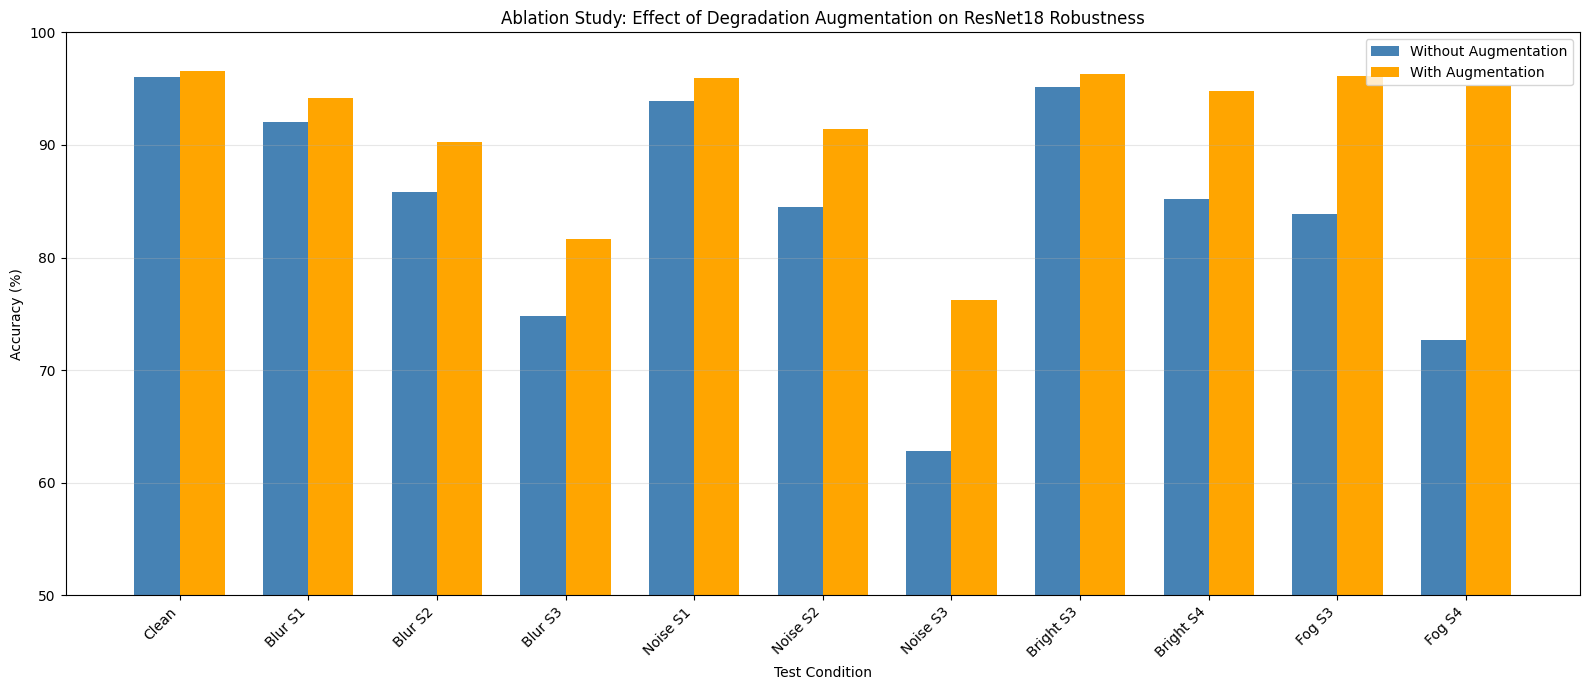

Ablation plot saved!


In [8]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['Clean', 'Blur S1', 'Blur S2', 'Blur S3', 
              'Noise S1', 'Noise S2', 'Noise S3',
              'Bright S3', 'Bright S4', 'Fog S3', 'Fog S4']

original = [95.99, 92.03, 85.84, 74.85, 93.86, 84.47, 62.83, 95.14, 85.21, 83.90, 72.64]
augmented = [96.56, 94.16, 90.27, 81.69, 95.94, 91.45, 76.22, 96.33, 94.81, 96.15, 95.27]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width/2, original, width, label='Without Augmentation', color='steelblue')
bars2 = ax.bar(x + width/2, augmented, width, label='With Augmentation', color='orange')

ax.set_xlabel('Test Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Ablation Study: Effect of Degradation Augmentation on ResNet18 Robustness')
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=45, ha='right')
ax.legend()
ax.set_ylim(50, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ablation plot saved!")